# Pipeline checkpointing

This notebook demonstrates how to save and restore the state of a DALI *pipeline-mode* data preparation job. A pipeline checkpoint captures the state of every stateful operator - the iteration position of each reader and the internal state of every random number generator - so that processing can resume from exactly the point where it was interrupted.

The example reads JPEG images from `DALI_EXTRA_PATH/db/single/mixed` with `fn.readers.file`, decodes them, and applies a rotation by a random angle in the range `(-30, 30)` degrees. We will run the pipeline for a couple of warmup iterations, save a checkpoint, and then build a fresh pipeline that resumes from exactly the captured point. For a full description of the API see [the checkpointing documentation page](../../advanced_topics_checkpointing.rst).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from nvidia.dali import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types

IMAGE_DIR = os.path.join(os.environ["DALI_EXTRA_PATH"], "db", "single", "mixed")
BATCH_SIZE = 8

## Building the pipeline

The pipeline reads files with `fn.readers.file`, decodes them, draws a random rotation angle with `fn.random.uniform`, and applies `fn.rotate`. Returning the labels and the angles as additional outputs lets us later confirm that the reader resumed at the same file and that the RNG produced the same draws after the checkpoint was restored. Pass `enable_checkpointing=True` to `pipeline_def` to allow the pipeline to capture its state on demand.

In [2]:
@pipeline_def(
    batch_size=BATCH_SIZE,
    num_threads=4,
    device_id=0,
    enable_checkpointing=True,
    seed=12,
)
def rotate_pipeline():
    jpegs, labels = fn.readers.file(
        file_root=IMAGE_DIR,
        random_shuffle=True,
    )
    images = fn.decoders.image(jpegs, device="mixed", output_type=types.RGB)
    angles = fn.random.uniform(range=(-30.0, 30.0))
    rotated = fn.rotate(images, angle=angles, fill_value=0)
    return rotated, labels, angles

## Saving a checkpoint

We build the pipeline and let it run for a couple of warmup iterations to advance the reader and the random number generator past their initial state. Only then do we take the checkpoint - this makes the test below more meaningful, as a pipeline that has not yet run would obviously match a freshly built one. `Pipeline.checkpoint` returns the serialized checkpoint and, if a filename is supplied, also writes it to disk.

In [3]:
pipe = rotate_pipeline()
pipe.build()

warmup_iters = 3
for _ in range(warmup_iters):
    pipe.run()

checkpoint = pipe.checkpoint("pipeline_checkpoint.cpt")
print("Saved checkpoint to pipeline_checkpoint.cpt")

Saved checkpoint to pipeline_checkpoint.cpt


## Restoring the state

In the previous step we've saved the state of the pipeline. Once we restore that state in a new pipeline, the _next_ batch it will produce will be the same as in the original pipeline. Let's run a comparison.

### Producing a reference batch

We pull one more batch out of the original pipeline. This is the batch we will compare against the first batch produced by the restored pipeline.

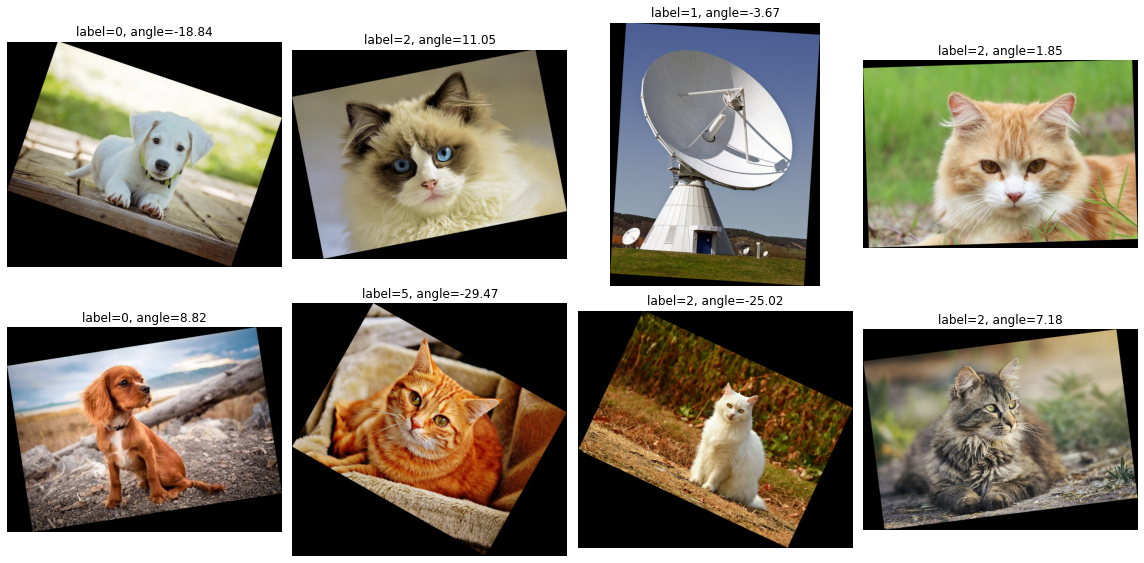

In [4]:
ref_images, ref_labels, ref_angles = pipe.run()


def to_numpy_list(tensor_list):
    if hasattr(tensor_list, "as_cpu"):
        tensor_list = tensor_list.as_cpu()
    return [np.array(tensor_list[i]) for i in range(len(tensor_list))]


ref_label_values = [int(t.flatten()[0]) for t in to_numpy_list(ref_labels)]
ref_angle_values = [float(t.flatten()[0]) for t in to_numpy_list(ref_angles)]

images_np = to_numpy_list(ref_images)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_np[i])
    ax.set_title(f"label={ref_label_values[i]}, angle={ref_angle_values[i]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Restoring from the checkpoint

On the restore side we build a new pipeline instance from the same factory and pass the serialized checkpoint via the `checkpoint=` argument. The restored pipeline picks up exactly where the original one left off.

In [5]:
restored = rotate_pipeline(checkpoint=checkpoint)
restored.build()

rest_images, rest_labels, rest_angles = restored.run()

rest_label_values = [int(t.flatten()[0]) for t in to_numpy_list(rest_labels)]
rest_angle_values = [float(t.flatten()[0]) for t in to_numpy_list(rest_angles)]

## Verifying the resume

The labels track which files the reader picked, in order - matching labels mean the reader resumed at the right position and kept the same shuffle. Matching angles mean the RNG was restored to the same internal state.

In [6]:
print("labels (original): ", ref_label_values)
print("labels (restored): ", rest_label_values)
print("angles (original): ", [f"{a:.4f}" for a in ref_angle_values])
print("angles (restored): ", [f"{a:.4f}" for a in rest_angle_values])

assert ref_label_values == rest_label_values, "reader order diverged"
assert ref_angle_values == rest_angle_values, "RNG state diverged"
print("\nFile order and random angles match exactly.")

labels (original):  [0, 2, 1, 2, 0, 5, 2, 2]
labels (restored):  [0, 2, 1, 2, 0, 5, 2, 2]
angles (original):  ['-18.8415', '11.0461', '-3.6668', '1.8544', '8.8177', '-29.4673', '-25.0191', '7.1832']
angles (restored):  ['-18.8415', '11.0461', '-3.6668', '1.8544', '8.8177', '-29.4673', '-25.0191', '7.1832']

File order and random angles match exactly.


Finally, let's display the output.

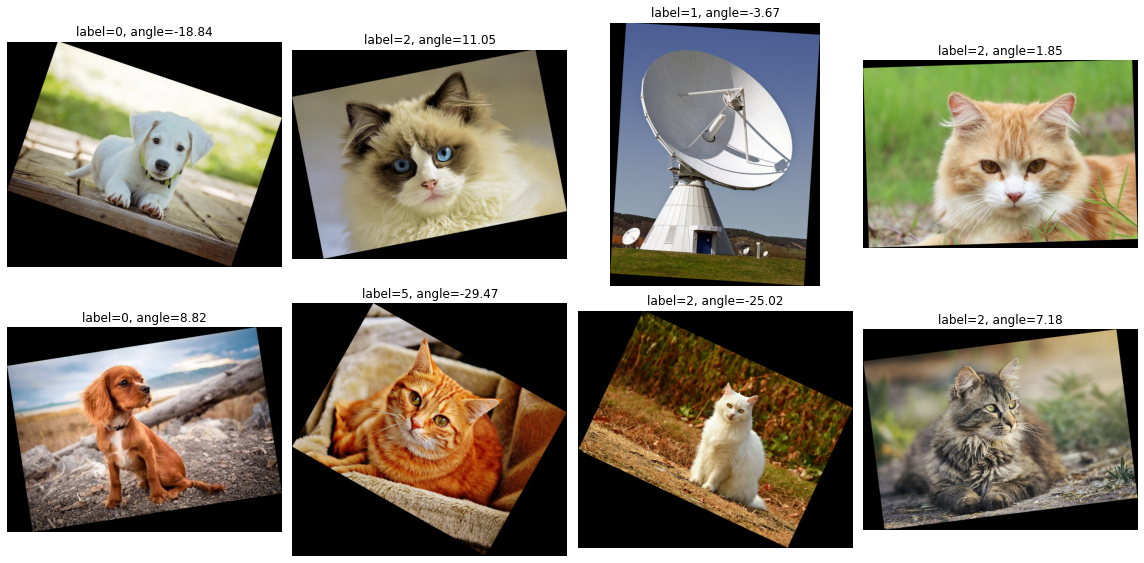

In [7]:
images_np = to_numpy_list(rest_images)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_np[i])
    ax.set_title(f"label={rest_label_values[i]}, angle={rest_angle_values[i]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()